# LLM 개요와 모델 활용 비교

대규모 언어 모델(LLM, Large Language Model)은 방대한 텍스트에서 다음 토큰을 예측하도록 학습해 문장을 이해하고 생성하는 인공지능 모델이다. 여기서 토큰(token)은 모델이 처리하는 텍스트 조각이며, 파라미터(parameter)는 학습 과정에서 조정되는 수치이다. 모델이 커질수록 더 다양한 언어 패턴을 표현할 가능성이 커지지만, 비용·지연 시간·운영 난이도도 함께 커진다.

LLM은 번역, 요약, 질의응답, 코드 보조, 문서 분석처럼 자연어를 입력과 출력으로 사용하는 업무에 쓰인다. 강점은 하나의 모델로 여러 언어 과제를 처리할 수 있다는 점이고, 한계는 그럴듯하지만 사실과 다른 내용을 만들 수 있다는 점, 최신 정보가 자동으로 보장되지 않는다는 점, 외부 서비스 사용 시 데이터와 비용을 관리해야 한다는 점이다.

이번 실습은 OpenAI API 키를 안전하게 준비해 짧은 Responses API 호출을 수행하고, 모델 크기와 공급사별 응답 특성을 비교하며, 공개 웹 데이터로 간단한 시각화 요청을 수행하는 흐름을 다룬다. 모델의 답변은 정답으로 바로 사용하지 않고 사실성·형식·비용·응답 시간을 함께 검토해야 한다.


## 모델 규모와 실행 위치에 따른 구분

언어 모델을 LLM, SLM 또는 On-device AI로 구분할 때는 파라미터 수만으로 경계를 고정하지 않는다. 파라미터 수는 모델이 학습한 수치의 개수이며, `B`는 10억(billion)을 뜻한다. 파라미터가 많으면 더 복잡한 패턴을 표현할 가능성이 커지지만, 실제 성능은 학습 데이터, 학습 방법, 모델 구조, 양자화와 사용 과제에도 영향을 받는다. 따라서 `몇 B 이상이면 무조건 LLM이다`와 같은 기준보다 모델의 능력, 실행 비용, 지연 시간과 배포 목적을 함께 살펴야 한다.

### LLM

대규모 언어 모델(LLM, Large Language Model)은 대량의 데이터와 많은 파라미터를 사용해 다양한 언어 과제를 처리하도록 만든 모델이다. 번역, 요약, 질의응답, 코드 생성처럼 범용성이 필요한 작업에 적합하지만, 학습과 추론에 많은 연산 자원이 필요하며 외부 API로 사용하면 호출 비용과 데이터 전송 범위를 관리해야 한다.

### sLLM(SLM)

작은 LLM이라는 뜻으로 sLLM(Small LLM) 또는 SLM(Small Language Model)이라고 부른다. LLM보다 파라미터 수와 자원 요구량을 줄인 소형 언어 모델이다. sLLM은 특정 도메인이나 반복 업무에 맞춰 파인튜닝하고 자체 인프라에서 운영하기 쉽지만, 작은 크기만으로 정확도나 일반화가 보장되지는 않는다. 데이터가 좁거나 품질이 낮으면 파인튜닝 뒤 다른 과제의 성능이 떨어질 수 있다.

### On-device AI

On-device AI는 모델의 크기보다 **모델이 실행되는 위치**에 초점을 둔 표현이다. 스마트폰, 노트북, 자동차나 임베디드 장치 안에서 직접 추론하므로 네트워크가 없어도 동작할 수 있고, 입력 데이터를 외부 서버로 보내지 않아도 된다. 제한된 메모리와 전력 안에서 실행해야 하므로 소형 모델, 양자화와 하드웨어 가속을 자주 사용하지만, 특정 파라미터 수만으로 On-device 모델을 정의하지 않는다.

|구분|핵심 목적|장점|주요 한계|적합한 사용 맥락|
|---|---|---|---|---|
|LLM|여러 과제를 처리하는 범용 능력|복잡한 지시와 다양한 과제 처리|높은 연산량·비용·지연 시간|범용 질의응답, 문서 분석, 고난도 생성|
|SLM·sLLM|작은 자원으로 특정 업무 수행|자체 운영과 도메인 최적화가 비교적 쉬움|범용성과 복잡한 추론이 제한될 수 있음|사내 업무, 도메인 특화, 비용 민감 서비스|
|On-device AI|사용자 장치에서 직접 추론|낮은 지연, 오프라인 실행, 데이터 외부 전송 최소화|메모리·전력·모델 크기 제약|모바일 보조 기능, 현장 장비, 개인화 기능|

범용성과 복잡한 작업 품질을 우선하면 LLM을 먼저 검토한다. 자체 배포, 반복 비용이나 도메인 맞춤이 중요하면 sLLM을 검토하고, 오프라인 실행과 즉각적인 반응 또는 장치 밖으로 데이터를 보내지 않는 조건이 핵심이면 On-device 경로를 검토한다. 이 세 구분은 완전히 배타적이지 않다. 하나의 sLLM을 On-device 환경에 배포할 수도 있다.

## 공개 범위와 제공 방식에 따른 구분

### 개방형 LLM 모델, 오픈 웨이트 모델

- 개방형 LLM 모델은 라이선스가 허용하는 범위에서 코드나 모델 자산을 확인하고 수정할 수 있는 모델이다.
- 오픈 웨이트 모델은 특히 학습된 가중치를 내려받아 자체 서버나 클라우드에서 실행할 수 있다는 뜻이다.
  - 가중치가 공개되어도 학습 데이터, 전체 학습 코드나 상업적 이용 권한까지 자동으로 공개되는 것은 아니므로 모델별 라이선스를 반드시 확인해야 한다.
- 자체 배포와 파인튜닝의 자유도가 높은 대신 GPU, 보안 업데이트, 장애 대응과 모델 서빙을 직접 책임져야 한다.

### 폐쇄형 LLM 모델

- 폐쇄형 LLM 모델은 공급자가 가중치와 핵심 학습 시스템을 공개하지 않고 운영하는 모델이다.
- 사용자는 API 키로 요청을 보내고 응답을 받는다.
- 초기 인프라 구축 없이 높은 성능의 모델과 관리 기능을 빠르게 사용할 수 있지만, 지원 기능과 사용 정책이 공급자에게 의존하고 호출 비용, 데이터 전송 범위와 서비스 변경 가능성을 관리해야 한다.

|비교 기준|개방형·오픈 웨이트 모델|폐쇄형 API 모델|
|---|---|---|
|모델 접근|라이선스 범위에서 가중치를 내려받아 실행할 수 있음|가중치에 접근하지 않고 API나 웹으로 사용함|
|커스터마이징|직접 파인튜닝, 양자화와 서빙 구성을 선택할 수 있음|공급자가 제공하는 파인튜닝과 설정 범위 안에서 사용함|
|운영 책임|인프라, 배포, 모니터링과 보안 대응을 사용자가 담당함|모델 인프라는 공급자가 담당하고 사용자는 연동 코드를 관리함|
|데이터 경로|자체 환경 안에 데이터를 둘 수 있으나 내부 보안 체계가 필요함|요청 데이터가 외부 서비스로 전송되므로 정책과 보관 조건을 확인해야 함|
|비용 구조|모델 사용료 외에 GPU와 운영 인력 비용을 직접 부담함|주로 요청량과 토큰 사용량에 따라 비용을 부담함|
|주요 선택 이유|자체 배포, 세밀한 제어, 도메인 파인튜닝|빠른 개발, 관리 부담 감소, 공급자의 최신 기능 활용|


## 현행 모델 스냅샷 (2026-08-02 기준)

|공급자|모델|선택 맥락|
|---|---|---|
|OpenAI|GPT-5.6 Sol|프런티어 수준의 복잡한 과제 검토|
|OpenAI|GPT-5.6 Terra|성능·비용·지연의 균형이 필요한 경로|
|OpenAI|GPT-5.6 Luna|비용 민감 또는 대량 처리 경로|
|Anthropic|Claude Fable 5|최고 난도의 장기 추론·장시간 에이전트 작업|
|Anthropic|Claude Opus 5|복잡한 분석·에이전틱 코딩·기업 업무|
|Anthropic|Claude Sonnet 5|성능·속도의 균형이 필요한 일반 프로덕션 경로|
|Anthropic|Claude Haiku 4.5|빠른 응답·대량 처리·비용 및 지연 민감 경로|
|Google|Gemini 3.6 Flash|공식 페이지가 최신 Flash로 소개하는 경로|

공식 정보는 [OpenAI 모델 카탈로그](https://developers.openai.com/api/docs/models), [Claude 모델 문서](https://platform.claude.com/docs/en/about-claude/models/overview), [Gemini 모델 문서](https://ai.google.dev/gemini-api/docs/models)에서 확인한다.


## LLM의 학습과 활용 경로

대규모 언어 모델(LLM)은 많은 텍스트에서 다음 토큰을 예측하도록 학습한 모델이다. 사전학습은 일반 언어 패턴을 얻는 단계이고, In-context Learning은 학습된 가중치를 바꾸지 않은 채 프롬프트 안의 지시와 예시로 현재 과제를 푸는 단계이다.

이 구분이 필요한 이유는 같은 질문 품질 문제라도 해결 위치가 다르기 때문이다. 이어지는 예시는 프롬프트의 예시만 바꿔 출력 형식을 유도하는 ICL을 보이고, 뒤의 환각 보완은 모델이 모르는 사실을 외부 근거로 연결하는 방법을 보인다.


### Pre-training과 In-context Learning

Pre-training은 웹 문서·책·코드처럼 대량의 텍스트에서 토큰 (x_t) 앞의 문맥 (x_{<t})을 보고 다음 토큰의 확률 (P(x_t|x_{<t}))을 높이는 과정이다. 이 단계는 보통 대규모 연산이 필요하므로 여기서는 직접 재현하지 않는다. ICL은 모델 파라미터를 업데이트하지 않으며, 시스템 지시와 few-shot 예시를 입력 문맥에 넣어 과제와 출력 형식을 맞춘다.


In [9]:
examples = [
    {'입력': '배송이 빨라요', '감성': '긍정'},
    {'입력': '포장이 찢어졌어요', '감성': '부정'},
]
query = '가격 대비 만족합니다'
prompt = '\n'.join(f"리뷰: {row['입력']} -> 감성: {row['감성']}" for row in examples)
# 예시의 입력-출력 형식을 한 개의 프롬프트 문자열로 연결한다.
prompt += f'\n리뷰: {query} -> 감성:'
print(prompt)


리뷰: 배송이 빨라요 -> 감성: 긍정
리뷰: 포장이 찢어졌어요 -> 감성: 부정
리뷰: 가격 대비 만족합니다 -> 감성:


### 환각과 보완

환각은 모델이 그럴듯하지만 근거가 없거나 틀린 내용을 생성하는 현상이다. 확률적으로 자연스러운 다음 토큰을 고르는 목적은 사실 검증을 보장하지 않으므로, 최신 사실·사내 규정·정확한 인용이 필요한 질문에는 검색 증강 생성(RAG), 도구 호출, 출처 표시와 사람이 확인하는 절차를 함께 사용한다.

예를 들어 사내 휴가 규정 질문은 모델의 기억으로 답하지 않고, 승인된 규정 문서를 검색해 문서 조각과 출처를 함께 답변에 넣는다. 검색 결과가 없으면 답을 추측하지 않고 근거 부족을 말하는 것이 안전하다.


In [10]:
retrieved_sources = []
answer_policy = '근거 문서가 없으므로 답변을 보류하고 담당 문서 또는 사람 검토를 요청한다.' if not retrieved_sources else '검색된 근거를 인용하여 답변한다.'
# 검색 근거가 없으면 응답을 보류하는 정책을 만든다.
print(answer_policy)


근거 문서가 없으므로 답변을 보류하고 담당 문서 또는 사람 검토를 요청한다.


### 최신 모델 정보 확인 원칙

모델 이름, 컨텍스트 길이, 가격, 지원 기능은 빠르게 바뀐다. 모델 이름, 가격, 지원 기능을 사용할 때는 **2026-08-02 기준 정보도 실행 전 각 공급자의 공식 문서로 다시 확인한다**. 특정 최신 모델이나 가격을 변하지 않는 정답처럼 하드코딩하지 않는다.


## LLM Vendor별 테스트

1. **번역** :

   ```text
   The dominant sequence transduction models are based on complex recurrent or
   convolutional neural networks that include an encoder and a decoder. The best
   performing models also connect the encoder and decoder through an attention
   mechanism. We propose a new simple network architecture, the Transformer,
   based solely on attention mechanisms, dispensing with recurrence and convolutions
   entirely. Experiments on two machine translation tasks show these models to
   be superior in quality while being more parallelizable and requiring significantly
   less time to train. Our model achieves 28.4 BLEU on the WMT 2014 Englishto-German translation task, improving over the existing best results, including
   ensembles, by over 2 BLEU. On the WMT 2014 English-to-French translation task,
   our model establishes a new single-model state-of-the-art BLEU score of 41.8 after
   training for 3.5 days on eight GPUs, a small fraction of the training costs of the
   best models from the literature. We show that the Transformer generalizes well to
   other tasks by applying it successfully to English constituency parsing both with
   large and limited training data.

   영어로 작성된 과학 저널 논문 초록을 한국어로 번역하되, 전문 용어(예: “photovoltaic efficiency”, “bandgap engineering”)를 정확하게 반영하고, 논문 특유의 딱딱한 문체를 유지하라.
   ```
   - [Deep Residual Learning for Image Recognition](https://arxiv.org/pdf/1512.03385)
   - [Attention Is All You Need](https://arxiv.org/pdf/1706.03762)

2. **코드 생성 (난이도 중상)**

   ```text
   최근 비트코인 가격데이터를 가져와서 시각화 하는 코드를 작성해줘.
   - 설치가 필요한 라이브러리가 있는 경우, 설치코드 역시 작성할 것!
   ```

3. **창의적 글짓기**

   ```text
   “인간과 로봇이 공존하는 미래 도시”를 배경으로,
   200자 내외의 짧은 SF 단편을 한 편 써줘.
   ```

4. **요약**

   ```text
   아래 기술 블로그 글을 3문장 이내로 간결하게 요약해줘:
   “머신러닝 모델의 과적합(overfitting) 문제를 해결하기 위해 정규화(regularization) 기법이 어떻게 사용되는지, L1/L2 페널티의 차이와 장단점을 사례를 들어 설명한다.”
   ```
5. **환각**

   ```text
   현재 대한민국 대통령이 누구야?
   강남에 유명한 성형외과 의사 오지명에 대해 알려줘
   ```
   - knowledge cutoff 이후 이벤트에 대한 질문

## LLM이 생성해준 코드 확인

### OpenAI ChatGPT

In [11]:
# %pip install yfinance pandas matplotlib

최근 데이터
                                   Open          High           Low  \
Date                                                                  
2026-07-30 00:00:00+00:00  63908.625000  65071.445312  63533.906250   
2026-07-31 00:00:00+00:00  64723.968750  65328.183594  62410.867188   
2026-08-01 00:00:00+00:00  62813.664062  63091.597656  62233.011719   
2026-08-02 00:00:00+00:00  62763.445312  63714.613281  62745.253906   
2026-08-04 00:00:00+00:00  63463.722656  64104.531250  63292.660156   

                                  Close       Volume  Dividends  Stock Splits  
Date                                                                           
2026-07-30 00:00:00+00:00  64725.308594  26250039650        0.0           0.0  
2026-07-31 00:00:00+00:00  62813.746094  30439749629        0.0           0.0  
2026-08-01 00:00:00+00:00  62763.320312  13553286543        0.0           0.0  
2026-08-02 00:00:00+00:00  63482.000000  15901776708        0.0           0.0  
2026-08-04 00:0

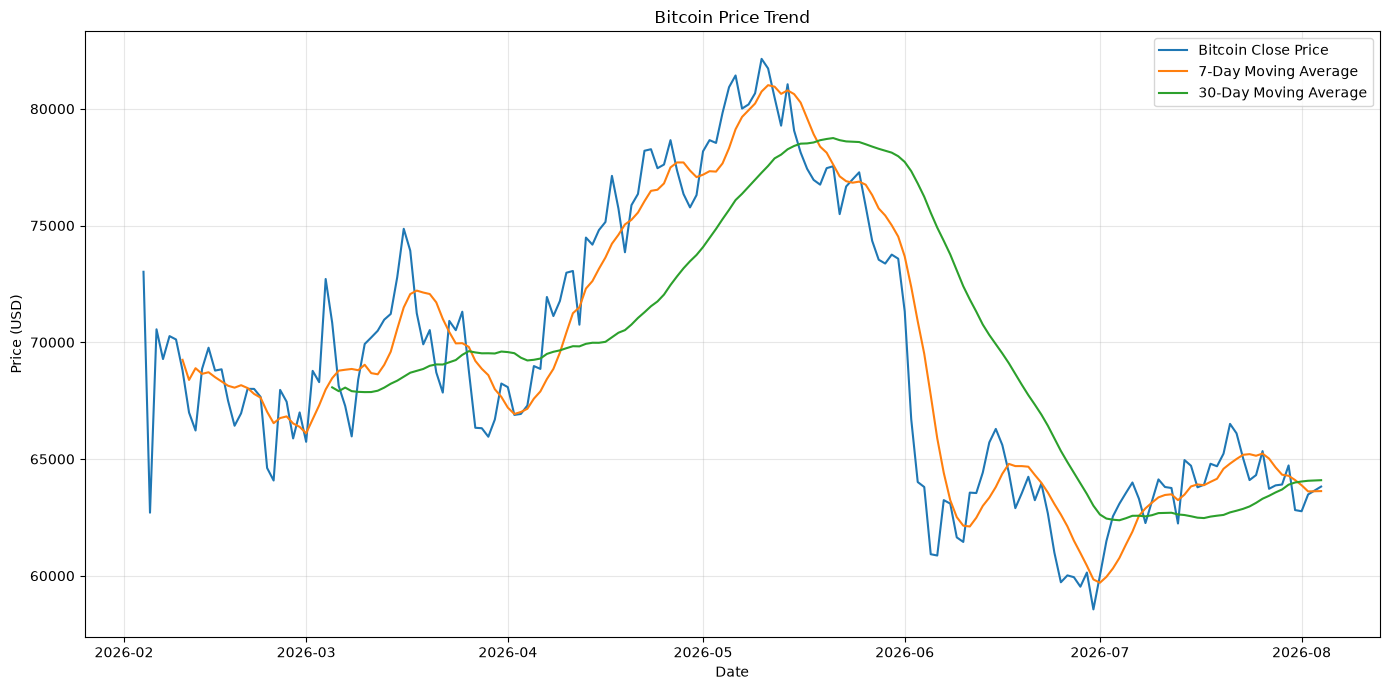

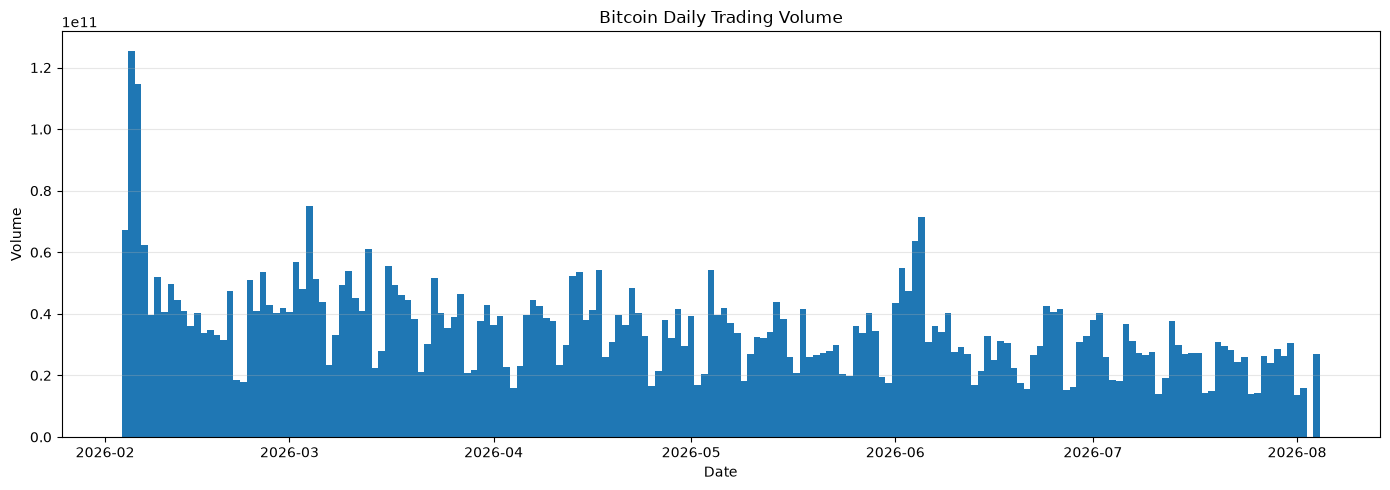

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


# --------------------------------------------------
# 1. 비트코인 가격 데이터 가져오기
# --------------------------------------------------
ticker = "BTC-USD"

bitcoin = yf.Ticker(ticker)

# 최근 6개월간의 일별 데이터
df = bitcoin.history(
    period="6mo",
    interval="1d",
    auto_adjust=True
)

# 데이터가 정상적으로 조회되었는지 확인
if df.empty:
    raise ValueError("비트코인 가격 데이터를 가져오지 못했습니다.")


# --------------------------------------------------
# 2. 데이터 확인
# --------------------------------------------------
print("최근 데이터")
print(df.tail())

print("\n데이터 컬럼")
print(df.columns)

print("\n데이터 크기")
print(df.shape)


# --------------------------------------------------
# 3. 이동평균 계산
# --------------------------------------------------
df["MA7"] = df["Close"].rolling(window=7).mean()
df["MA30"] = df["Close"].rolling(window=30).mean()


# --------------------------------------------------
# 4. 종가와 이동평균 시각화
# --------------------------------------------------
plt.figure(figsize=(14, 7))

plt.plot(
    df.index,
    df["Close"],
    label="Bitcoin Close Price",
    linewidth=1.5
)

plt.plot(
    df.index,
    df["MA7"],
    label="7-Day Moving Average",
    linewidth=1.5
)

plt.plot(
    df.index,
    df["MA30"],
    label="30-Day Moving Average",
    linewidth=1.5
)

plt.title("Bitcoin Price Trend")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 5. 거래량 시각화
# --------------------------------------------------
plt.figure(figsize=(14, 5))

plt.bar(
    df.index,
    df["Volume"],
    width=1.0
)

plt.title("Bitcoin Daily Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Google Deepmind Gemini

In [13]:
# %pip install yfinance pandas matplotlib mplfinance

BTC-USD: Period '6m' is invalid, must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BTC-USD']: Period '6m' is invalid, must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max


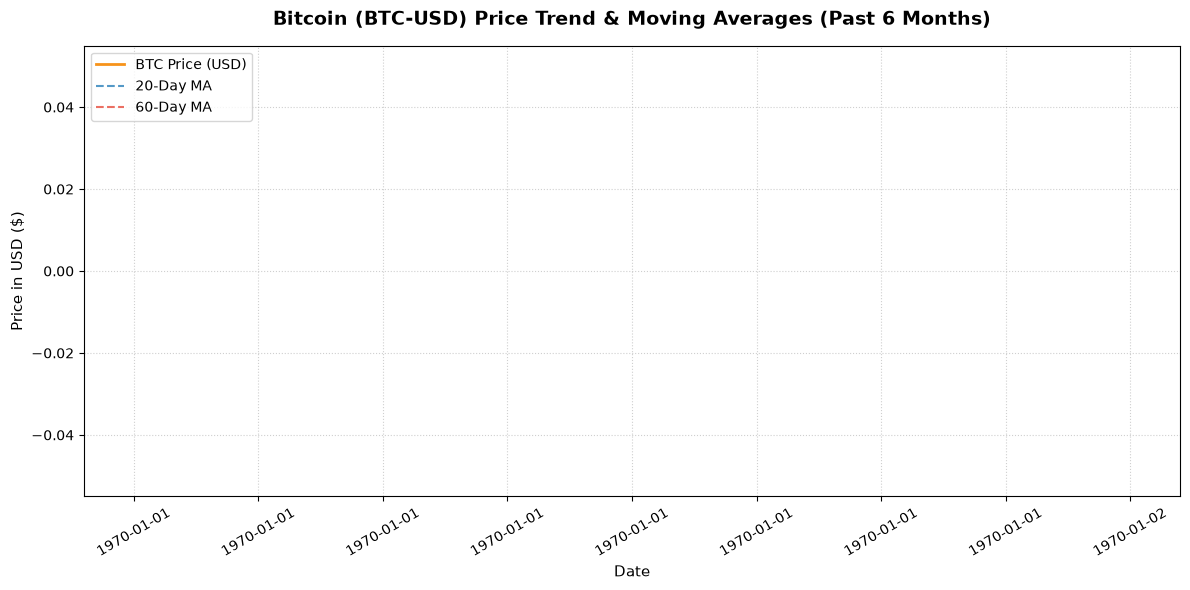

In [14]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 비트코인(BTC-USD) 최근 6개월 데이터 수집
df = yf.download("BTC-USD", period="6m")

# MultiIndex 칼럼 정리 (yfinance 최신 버전 호환용)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 2. 20일 및 60일 이동평균선(Moving Average) 계산
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA60'] = df['Close'].rolling(window=60).mean()

# 3. 차트 그려내기
plt.figure(figsize=(12, 6))

# 비트코인 종가, MA20, MA60 플롯
plt.plot(df.index, df['Close'], label='BTC Price (USD)', color='#F7931A', linewidth=2)
plt.plot(df.index, df['MA20'], label='20-Day MA', color='#2980B9', linestyle='--', alpha=0.8)
plt.plot(df.index, df['MA60'], label='60-Day MA', color='#E74C3C', linestyle='--', alpha=0.8)

# 차트 스타일 지정
plt.title('Bitcoin (BTC-USD) Price Trend & Moving Averages (Past 6 Months)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Price in USD ($)', fontsize=11)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# 날짜 라벨 회전 및 그리드 설정
plt.xticks(rotation=30)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

In [1]:
import yfinance as yf
import mplfinance as mpf
import pandas as pd
# 1. 최근 3개월 데이터 다운로드
df = yf.download("BTC-USD", period="3m")

# 2. 캔들차트 + 이동평균선(20, 60일) + 거래량(Volume) 시각화
mpf.plot(
    df,
    type='candle',             # 차트 형태: 'candle', 'line', 'renko' 등 가능
    style='charles',            # 스타일: 'charles', 'yahoo', 'nightclouds' 등
    title='Bitcoin (BTC-USD) Candlestick Chart',
    ylabel='Price (USD)',
    ylabel_lower='Volume',
    volume=True,                # 하단 거래량 표시 여부
    mav=(20, 60),               # 이동평균선 20일, 60일 추가
    figratio=(12, 6),
    tight_layout=True
)

BTC-USD: Period '3m' is invalid, must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BTC-USD']: Period '3m' is invalid, must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max


ValueError: Data for column "Open" must be ALL float or int.

### Anthropic Claude

                                   Open          High           Low  \
Date                                                                  
2026-08-02 00:00:00+00:00  62763.445312  63714.613281  62745.253906   
2026-08-03 00:00:00+00:00  63485.441406  64020.324219  62226.578125   
2026-08-04 00:00:00+00:00  63458.410156  64466.937500  63277.683594   
2026-08-05 00:00:00+00:00  64054.878906  64954.347656  63829.718750   
2026-08-06 00:00:00+00:00  64602.320312  64922.953125  64438.773438   

                                  Close       Volume  Dividends  Stock Splits  
Date                                                                           
2026-08-02 00:00:00+00:00  63482.000000  15901776708        0.0           0.0  
2026-08-03 00:00:00+00:00  63460.898438  26038889824        0.0           0.0  
2026-08-04 00:00:00+00:00  64055.953125  23662357784        0.0           0.0  
2026-08-05 00:00:00+00:00  64597.500000  23568584891        0.0           0.0  
2026-08-06 00:00:00+00

C:\Users\leso0\AppData\Local\Temp\ipykernel_2488\2755197155.py:85: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\leso0\AppData\Local\Temp\ipykernel_2488\2755197155.py:85: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\leso0\AppData\Local\Temp\ipykernel_2488\2755197155.py:85: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\leso0\AppData\Local\Temp\ipykernel_2488\2755197155.py:85: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\leso0\AppData\Local\Temp\ipykernel_2488\2755197155.py:85: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\leso0\AppData\Local\Temp\ipykernel_2488\2755197155.py:85: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s

[완료] 차트가 'bitcoin_price_chart.png' 파일로 저장되었습니다.


C:\Users\leso0\miniforge3\envs\llm_env\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\leso0\miniforge3\envs\llm_env\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\leso0\miniforge3\envs\llm_env\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\leso0\miniforge3\envs\llm_env\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\leso0\miniforge3\envs\llm_env\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO

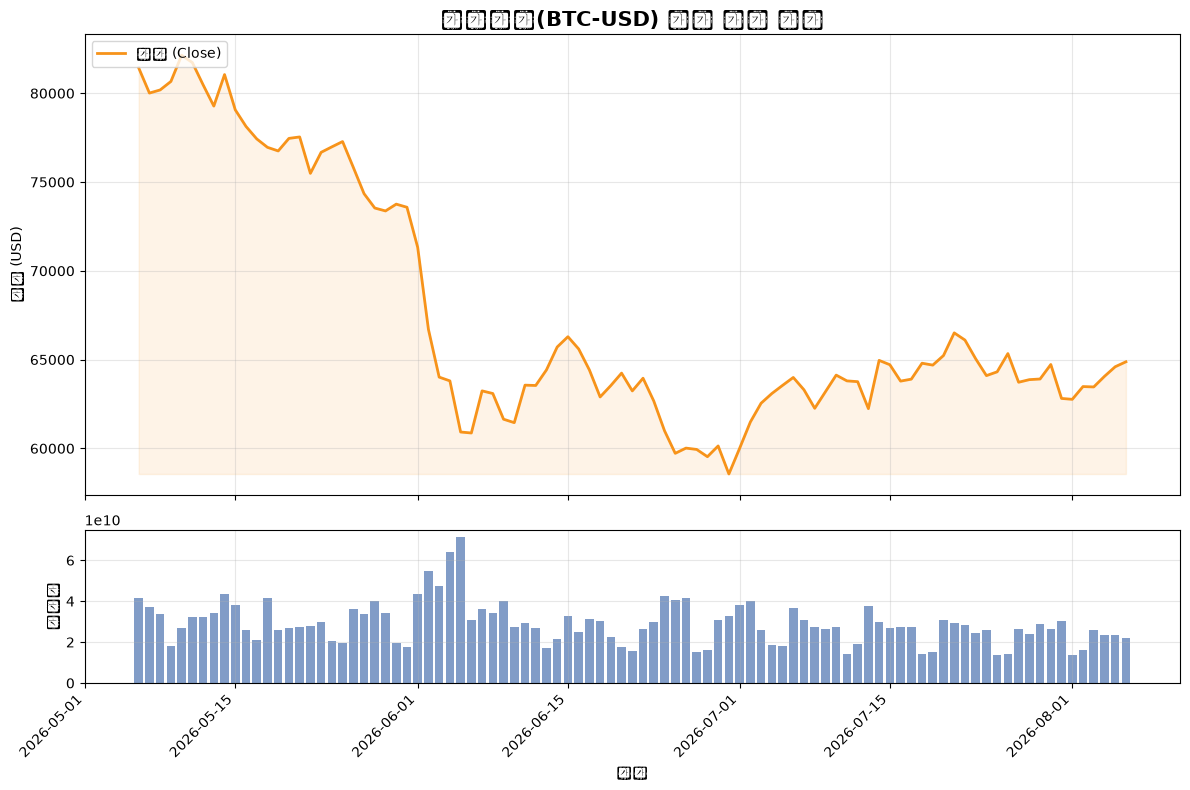

In [2]:
"""
비트코인(BTC-USD) 최근 가격 데이터를 가져와 시각화하는 스크립트

필요 라이브러리 설치:
    pip install yfinance matplotlib pandas --break-system-packages

(가상환경을 사용 중이라면 --break-system-packages 옵션은 생략 가능합니다.)
"""

import subprocess
import sys


def install_requirements():
    """필요한 라이브러리가 없을 경우 자동으로 설치합니다."""
    required = ["yfinance", "matplotlib", "pandas"]
    for package in required:
        try:
            __import__(package)
        except ImportError:
            print(f"[설치 중] {package} ...")
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", package, "--break-system-packages"]
            )


install_requirements()

import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd


def fetch_bitcoin_data(period: str = "3mo", interval: str = "1d") -> pd.DataFrame:
    """
    비트코인(BTC-USD) 가격 데이터를 가져옵니다.

    Parameters
    ----------
    period : str
        가져올 기간 (예: "1mo", "3mo", "6mo", "1y", "ytd", "max")
    interval : str
        데이터 간격 (예: "1d", "1h", "1wk")

    Returns
    -------
    pd.DataFrame
        날짜별 시가/고가/저가/종가/거래량 데이터
    """
    ticker = yf.Ticker("BTC-USD")
    df = ticker.history(period=period, interval=interval)

    if df.empty:
        raise ValueError("데이터를 가져오지 못했습니다. 인터넷 연결 또는 티커명을 확인하세요.")

    return df


def plot_bitcoin_data(df: pd.DataFrame, save_path: str = "bitcoin_price_chart.png"):
    """비트코인 종가 및 거래량을 시각화합니다."""

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
    )

    # 종가 라인 차트
    ax1.plot(df.index, df["Close"], color="#f7931a", linewidth=2, label="종가 (Close)")
    ax1.fill_between(df.index, df["Close"], df["Close"].min(), color="#f7931a", alpha=0.1)
    ax1.set_title("비트코인(BTC-USD) 최근 가격 추이", fontsize=15, fontweight="bold")
    ax1.set_ylabel("가격 (USD)")
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)

    # 거래량 바 차트
    ax2.bar(df.index, df["Volume"], color="#4c72b0", alpha=0.7)
    ax2.set_ylabel("거래량")
    ax2.set_xlabel("날짜")
    ax2.grid(True, alpha=0.3)

    # 날짜 축 포맷
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    fig.autofmt_xdate(rotation=45)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    print(f"[완료] 차트가 '{save_path}' 파일로 저장되었습니다.")
    plt.show()


if __name__ == "__main__":
    # 최근 3개월(1일 간격) 데이터를 가져와 시각화
    btc_df = fetch_bitcoin_data(period="3mo", interval="1d")

    print(btc_df.tail())  # 최근 데이터 미리보기

    plot_bitcoin_data(btc_df)

### OpenAI API로 첫 요청 보내기

OpenAI API는 프로그램이 인터넷을 통해 OpenAI 모델에 입력을 보내고 결과를 받는 통로이다. 웹 화면에서 직접 대화하는 대신 Python 코드가 요청을 만들기 때문에 같은 작업을 반복하거나 다른 서비스와 연결할 수 있다.

API 키는 요청을 보낸 프로젝트를 식별하고 사용 권한을 확인하는 비밀 값이다. 비밀번호와 같은 수준으로 관리하며 노트북 셀, Git 저장소, 메신저, 화면 캡처에 기록하지 않는다. 첫 API 실습은 **키 발급 → PyCharm 프로젝트의 `.env`에 저장 → 현재 커널로 불러오기 → 클라이언트 생성 → 짧은 요청 1회 → 응답과 토큰 사용량 확인** 순서로 진행한다.


#### 1. API 키를 발급하고 사용 상태를 확인한다

1. [OpenAI API Keys 대시보드](https://platform.openai.com/api-keys)에 로그인한다.
2. 사용할 프로젝트를 선택하거나 새 프로젝트를 만든다.
3. **Create new secret key**를 선택해 키를 발급한다.
4. 화면에 표시된 키를 암호 관리자나 운영체제의 안전한 비밀 저장소에 즉시 보관한다.
5. API 대시보드에서 프로젝트의 사용 가능 상태, 결제 설정, 사용 한도를 확인한다.

키가 노출되었다고 의심되면 해당 키를 즉시 폐기하고 새 키를 발급한다. 여러 사용자가 하나의 키를 공유하지 않고 각자 자신의 프로젝트와 키를 사용하는 것이 사용량 추적과 사고 대응에 안전하다.

> **2026-08-02 기준:** 발급 화면과 메뉴 이름은 바뀔 수 있으므로 실행 전에 [OpenAI 공식 Quickstart](https://developers.openai.com/api/docs/quickstart)에서 절차를 다시 확인한다.


#### 2. OpenAI SDK와 `.env` 로더를 설치한다

SDK(Software Development Kit)는 HTTP 요청과 응답 처리를 Python 객체로 감싸는 도구이다. `python-dotenv`는 프로젝트 최상위의 `.env` 파일을 현재 Python 프로세스의 환경 변수로 불러온다.

다음 셀은 PyCharm이 선택한 Jupyter 커널에 `openai`와 `python-dotenv`를 설치한다. macOS와 Windows 모두 같은 셀을 사용하며, 설치 후 import 오류가 계속되면 커널을 한 번 다시 시작한다.


In [ ]:
# OpenAI SDK와 dotenv를 현재 Jupyter 커널에 설치한다.
# %pip install -U openai python-dotenv


#### 3. PyCharm 프로젝트 최상위에 `.env` 파일을 만든다

PyCharm에서 `08_llm` 폴더를 프로젝트로 열고, 프로젝트 탐색기의 `08_llm`을 마우스 오른쪽 버튼으로 클릭해 `New → File`을 선택한다. 파일 이름은 `.env`로 지정하고 다음 한 줄을 작성한다.

```dotenv
OPENAI_API_KEY=본인이_발급받은_API_키
```

`.env`는 암호화된 비밀 저장소가 아니라 로컬 평문 설정 파일이다. 실제 파일은 Git·메신저·과제 제출물에 포함하지 않고, 값이 비어 있는 `.env.example`만 공유한다. 이 프로젝트의 `08_llm/.gitignore`는 `.env`를 제외하도록 구성되어 있다.

상세한 PyCharm 설정과 문제 해결 절차는 [`OPENAI_API_KEY_SETUP.md`](../../OPENAI_API_KEY_SETUP.md)에서 확인할 수 있다. 다음 셀은 `.env`를 찾아 현재 커널에 불러오고 `OPENAI_API_KEY`의 존재 여부만 검사한다.


In [3]:
import os

from dotenv import find_dotenv, load_dotenv

# 현재 작업 폴더와 상위 폴더에서 .env 파일을 찾는다.
dotenv_path = find_dotenv(usecwd=True)
if not dotenv_path:
    raise FileNotFoundError(
        "08_llm 프로젝트 최상위에 .env 파일을 만든 뒤 현재 셀을 다시 실행한다."
    )

load_dotenv(dotenv_path, override=False)

required_env_vars = [
# 키 값 자체를 출력하지 않고 환경 변수 존재만 검사한다.
    "OPENAI_API_KEY",
]
missing_env_vars = [name for name in required_env_vars if not os.getenv(name)]
if missing_env_vars:
    missing_names = ", ".join(missing_env_vars)
    raise RuntimeError(f".env 파일의 다음 변수를 확인한다: {missing_names}")

print("환경 변수 준비 완료")


환경 변수 준비 완료


#### 4. 환경 변수로 인증하는 클라이언트를 만든다

`OpenAI()`는 앞에서 설정한 `OPENAI_API_KEY` 환경 변수를 자동으로 읽는다. 키 값을 생성자 인자나 소스 코드에 직접 적지 않는 이유는 노트북 공유 과정에서 비밀 값이 유출되는 것을 막기 위해서이다.

다음 셀은 네트워크 요청을 보내지 않고 클라이언트 객체만 준비한다. 키가 없다면 원인을 바로 알 수 있도록 먼저 환경 변수를 검사한다.


In [4]:
import os
from openai import OpenAI

# OPENAI_API_KEY 환경 변수를 사용하는 클라이언트를 만든다.
if not os.getenv("OPENAI_API_KEY"):
    raise RuntimeError("OPENAI_API_KEY가 설정되지 않았다. 앞의 .env 설정 셀을 먼저 실행한다.")

client = OpenAI()
print("OpenAI 클라이언트 준비 완료")


OpenAI 클라이언트 준비 완료


#### 5. Responses API로 첫 질문을 보낸다

Responses API는 모델 이름과 입력을 받아 생성 결과를 반환한다. 이 예제의 기본값은 짧은 입문 실습의 지연과 비용을 줄이기 위해 `gpt-5.6-luna`로 둔다. [공식 모델 페이지](https://developers.openai.com/api/docs/models/gpt-5-mini)는 이 모델을 속도와 비용을 중시하는 경로로 설명하고 Responses API 지원을 표시한다.

모델 제공 상태와 접근 권한은 바뀔 수 있으므로 **2026-08-02 기준 선택**으로 기록하고, 실행 전에 [공식 모델 카탈로그](https://developers.openai.com/api/docs/models/all)를 다시 확인한다. 실제 호출에는 사용량이 발생하므로 짧은 입력으로 한 번만 실행한다.


In [5]:
MODEL = "gpt-5.6-luna"

prompt = "대규모 언어 모델과 일반 프로그램의 차이를 초보자에게 두 문장으로 설명해줘"

# client(OpenAI 객체) 요청 후 응답 받기
response = client.responses.create(
    model=MODEL,
    instructions="초보자가 이해할 수 있는 쉬운 한국어로 정확히 두 문장만 답한다",
    input=prompt,
    max_output_tokens=256
)

print("응답: ", response.output_text)

print("input_tokens: ", response.usage.input_tokens)
print("output_tokens: ", response.usage.output_tokens)
print("total_tokens: ", response.usage.total_tokens)

응답:  일반 프로그램은 사람이 정해 놓은 규칙과 절차에 따라 정해진 결과를 내지만, 대규모 언어 모델은 많은 글을 학습해 문맥에 맞는 답변을 만들어 냅니다.  
따라서 대규모 언어 모델은 다양한 질문에 유연하게 답할 수 있지만, 항상 정확한 것은 아니므로 결과를 확인해야 합니다.
input_tokens:  53
output_tokens:  87
total_tokens:  140


## (참고)LLM 평가

- 사람이 직접 평가 https://lmarena.ai/